# NBA Game Outcome Prediction: Modeling & Tuning


## setup

In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3,
                     'figure.dpi': 120, 'savefig.bbox': 'tight'})
C_HOME, C_AWAY = '#2E5C8A', '#C4553B'
os.makedirs('figs', exist_ok=True)
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

## load the prepared data

In [2]:
df = pd.read_csv('modeling_table.csv')
df['gameDate'] = pd.to_datetime(df['gameDate'])

feature_cols = [c for c in df.columns if c not in ['gameId','gameDate','home_win']]
X = df[feature_cols]
y = df['home_win']
print('Games:', len(df), '| Features:', len(feature_cols))

Games: 14041 | Features: 42


## time-based train/test split

A random split would let the model train on future games to predict past ones, which is leakage. So I sort by date and hold out the most recent 20% of games as the test set. 

In [3]:
cut = int(len(df) * 0.80)
X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

print(f'Train: {len(X_train)} games ({df.gameDate.iloc[0].date()} to {df.gameDate.iloc[cut-1].date()})')
print(f'Test:  {len(X_test)} games ({df.gameDate.iloc[cut].date()} to {df.gameDate.iloc[-1].date()})')

baseline_acc = y_test.mean() if y_test.mean() > 0.5 else 1 - y_test.mean()
print(f'\nBaseline (always predict home): {baseline_acc:.4f}')

Train: 11232 games (2015-10-29 to 2024-04-02)
Test:  2809 games (2024-04-02 to 2026-06-13)

Baseline (always predict home): 0.5511


## scale features (for the linear model)

Logistic regression works better on standardized features. Tree models don't need it. I fit the scaler on the training set only so no test information leaks in.

In [4]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

## baseline (untuned) models

fit all three at reasonable defaults to get reference numbers before tuning.

In [5]:
def quick_eval(name, model, Xte):
    proba = model.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    print(f'{name:20s} acc={accuracy_score(y_test,pred):.4f}  '
          f'auc={roc_auc_score(y_test,proba):.4f}  logloss={log_loss(y_test,proba):.4f}')

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train_s, y_train)
quick_eval('LogisticRegression', lr, X_test_s)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
quick_eval('RandomForest', rf, X_test)

xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                    eval_metric='logloss', random_state=RANDOM_STATE).fit(X_train, y_train)
quick_eval('XGBoost', xgb, X_test)

LogisticRegression   acc=0.6440  auc=0.6992  logloss=0.6239


RandomForest         acc=0.6383  auc=0.6954  logloss=0.6281


XGBoost              acc=0.6461  auc=0.6883  logloss=0.6326


## training curve

To see how the boosted model behaves during training, I held out the last 15% of the training data as a validation block (still in time order) and watch train and validation log-loss across boosting rounds. Where validation loss bottoms out and starts climbing is where the model begins overfitting.

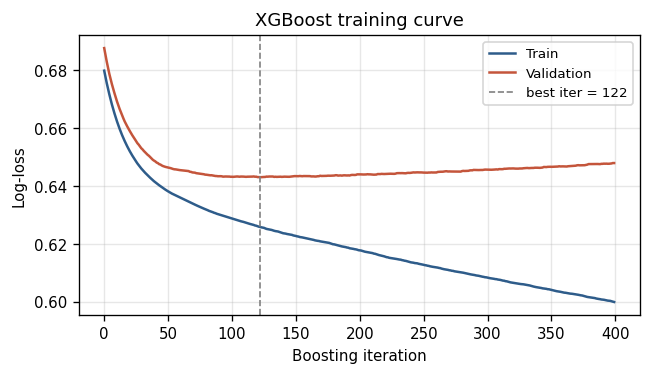

Validation log-loss bottoms out at 0.6431 on iteration 122


In [6]:
vcut = int(len(X_train) * 0.85)
Xtr2, Xval = X_train.iloc[:vcut], X_train.iloc[vcut:]
ytr2, yval = y_train.iloc[:vcut], y_train.iloc[vcut:]

xgb_curve = XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.03,
                          eval_metric='logloss', random_state=RANDOM_STATE)
xgb_curve.fit(Xtr2, ytr2, eval_set=[(Xtr2, ytr2), (Xval, yval)], verbose=False)

res = xgb_curve.evals_result()
tr_ll, va_ll = res['validation_0']['logloss'], res['validation_1']['logloss']
best_it = int(np.argmin(va_ll))

plt.figure(figsize=(5.5, 3.2))
plt.plot(tr_ll, label='Train', color=C_HOME, lw=1.5)
plt.plot(va_ll, label='Validation', color=C_AWAY, lw=1.5)
plt.axvline(best_it, ls='--', color='gray', lw=1, label=f'best iter = {best_it}')
plt.xlabel('Boosting iteration'); plt.ylabel('Log-loss')
plt.title('XGBoost training curve'); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figs/fig_training.pdf'); plt.show()

print(f'Validation log-loss bottoms out at {min(va_ll):.4f} on iteration {best_it}')

## hyperparameter tuning with TimeSeriesSplit

Normal cross-validation splits randomly, TimeSeriesSplit instead builds folds where each one trains on earlier games and validates on later ones. I tund on the training set only and score on ROC-AUC.

In [7]:
tscv = TimeSeriesSplit(n_splits=5)

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    {'C': [0.01, 0.1, 1.0, 10.0]},
    cv=tscv, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train_s, y_train)
print('LogReg  best:', lr_grid.best_params_, ' CV AUC:', round(lr_grid.best_score_, 4))

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {'n_estimators': [200, 400], 'max_depth': [5, 8, 12]},
    cv=tscv, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print('RF      best:', rf_grid.best_params_, ' CV AUC:', round(rf_grid.best_score_, 4))

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
    {'n_estimators': [200, 400], 'max_depth': [3, 5], 'learning_rate': [0.03, 0.1]},
    cv=tscv, scoring='roc_auc', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print('XGBoost best:', xgb_grid.best_params_, ' CV AUC:', round(xgb_grid.best_score_, 4))

LogReg  best: {'C': 0.01}  CV AUC: 0.6535


RF      best: {'max_depth': 5, 'n_estimators': 400}  CV AUC: 0.6558


XGBoost best: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200}  CV AUC: 0.6488


## save tuned predictions and models


In [8]:
test_out = pd.DataFrame({'y_true': y_test.values})
test_out['lr_proba']  = lr_grid.best_estimator_.predict_proba(X_test_s)[:, 1]
test_out['rf_proba']  = rf_grid.best_estimator_.predict_proba(X_test)[:, 1]
test_out['xgb_proba'] = xgb_grid.best_estimator_.predict_proba(X_test)[:, 1]
test_out.to_csv('test_predictions.csv', index=False)

meta = pd.DataFrame({
    'model': ['LogisticRegression','RandomForest','XGBoost'],
    'best_params': [str(lr_grid.best_params_), str(rf_grid.best_params_), str(xgb_grid.best_params_)],
    'cv_auc': [lr_grid.best_score_, rf_grid.best_score_, xgb_grid.best_score_],
})
meta.to_csv('model_meta.csv', index=False)

with open('baseline_acc.txt','w') as f:
    f.write(str(baseline_acc))

print('Saved: test_predictions.csv, model_meta.csv, baseline_acc.txt')

Saved: test_predictions.csv, model_meta.csv, baseline_acc.txt
